# CutBoost

В этом ноутбуке я буду обучать CutBoost модель, которая будет ранжировать отобранных IALS кандидатов. 

## Импорт библиотек

In [360]:
import numpy as np
import pandas as pd
import scipy 
import os
import sys
import pickle
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## Выгрузка данных

Выгрузка таблиц

In [323]:
clean_path = Path("../../../Tables/CleanTable")
items_dim = pd.read_csv(clean_path / "items_dim.csv")
items_stats = pd.read_csv(clean_path / "items_stats.csv")
users_clean = pd.read_csv(clean_path / "users_clean.csv")
user_item_year_clean = pd.read_csv(clean_path / "user_items_year_clean.csv")


In [324]:
items_dim.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 3 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   id_item                                235 non-null    int64
 1   Название услуги или товара             235 non-null    str  
 2   Категория товара или услуги в продаже  235 non-null    str  
dtypes: int64(1), str(2)
memory usage: 5.6 KB


In [325]:
items_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 9 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id_item                                235 non-null    int64  
 1   Название услуги или товара             235 non-null    str    
 2   Категория товара или услуги в продаже  235 non-null    str    
 3   Количество оказанных услуг             235 non-null    int64  
 4   Доля от оказанных услуг в %            235 non-null    float64
 5   Выручка от продажи услуг, руб          235 non-null    float64
 6   % от общей выручки за услуги           235 non-null    float64
 7   Ср. выручка с одного клиента, руб      235 non-null    float64
 8   Уникальные клиенты                     235 non-null    int64  
dtypes: float64(4), int64(3), str(2)
memory usage: 16.7 KB


In [326]:
users_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2711 entries, 0 to 2710
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_user          2711 non-null   int64  
 1   Имя              2711 non-null   str    
 2   Телефон          2711 non-null   str    
 3   Категории        2711 non-null   str    
 4   Оплачено в руб   2711 non-null   float64
 5   Последний визит  2711 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 127.2 KB


In [327]:
user_item_year_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 28760 entries, 0 to 28759
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Имя мастера            28760 non-null  str    
 1   Специализация мастера  28760 non-null  str    
 2   Имя клиента            28760 non-null  str    
 3   Время визита           28760 non-null  str    
 4   Категория услуги       28760 non-null  str    
 5   Название услуги        28760 non-null  str    
 6   Стоимость, руб         28760 non-null  float64
 7   Категория              28760 non-null  str    
 8   id_user                28760 non-null  int64  
 9   id_item                28760 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 2.2 MB


Выгрузка маппера

In [328]:
sys.path.append(str(Path.cwd().parent.parent))
from utils import IDMapper

In [329]:
mapper_path = Path('../../../results/mappers/id_mappers.pkl')
with open(mapper_path, "rb") as f:
    mappers = pickle.load(f)

user_mapper = mappers['user_mapper']
item_mapper = mappers['item_mapper']

Выгрузка IALS модели

In [330]:
model_path = Path('../../../results/models/IALS_model.pkl')
with open(model_path, "rb") as f:
    IALS_model = pickle.load(f)

Выгрузка sparse

In [331]:
sparse_path = Path("../../../results/matrices")
train_sparse = scipy.sparse.load_npz(sparse_path/'artnail_user_item_sparse_train.npz')
train_sparse.shape

(1265, 161)

## Feature Store

### Item Features

Сдесь мы позьмем items_stats за основу, т.к. он уже содержит id_item, название, категорию услуг и статистики по каждой услуге.

In [332]:
item_features = items_stats.copy()
item_features = item_features.drop(columns=['Выручка от продажи услуг, руб', '% от общей выручки за услуги'])

In [333]:
item_features.columns = [
    'id_item', 'item_name', 'item_category', 'item_count', 
    'item_share_pct', 'item_avg_revenue', 'item_unique_users'
]

In [334]:
item_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_item            235 non-null    int64  
 1   item_name          235 non-null    str    
 2   item_category      235 non-null    str    
 3   item_count         235 non-null    int64  
 4   item_share_pct     235 non-null    float64
 5   item_avg_revenue   235 non-null    float64
 6   item_unique_users  235 non-null    int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 13.0 KB


### User Features

In [335]:
user_features = users_clean[['id_user', 'Оплачено в руб', 'Последний визит']].copy()

Считаем days_since_last_visit - сколько дней клиент не был в салоне на момент конкретного визита

In [371]:
user_item_year_clean = user_item_year_clean.sort_values(['id_user', 'Время визита'])
user_item_year_clean['prev_visit_date'] = user_item_year_clean.groupby('id_user')['Время визита'].shift(1).astype('datetime64[ns]')
user_item_year_clean['Время визита'] = pd.to_datetime(user_item_year_clean['Время визита'])

In [374]:
user_item_year_clean['days_since_last_visit_real'] = (
    user_item_year_clean['Время визита'] - user_item_year_clean['prev_visit_date']
).dt.days

In [376]:
user_item_year_clean['days_since_last_visit_real'] = user_item_year_clean['days_since_last_visit_real'].fillna(365)

In [377]:
user_item_year_clean['days_since_last_visit_real'].value_counts()

days_since_last_visit_real
0.0      17799
365.0     2448
1.0        242
20.0       241
28.0       236
         ...  
219.0        1
256.0        1
249.0        1
221.0        1
251.0        1
Name: count, Length: 237, dtype: int64

In [384]:
test_user_id = user_item_year_clean['id_user'].value_counts().index[555]

check_df = user_item_year_clean[user_item_year_clean['id_user'] == test_user_id][
    ['id_user', 'Время визита', 'prev_visit_date', 'days_since_last_visit_real']
]

print(f"Проверка для пользователя {test_user_id}:")
display(check_df.head(10))

Проверка для пользователя 430:


,id_user,Время визита,prev_visit_date,days_since_last_visit_real
4523,430,2025-07-18 18:00:00,NaT,365.0
4536,430,2025-08-26 18:00:00,2025-07-18 18:00:00,39.0
4538,430,2025-08-26 18:00:00,2025-08-26 18:00:00,0.0
4524,430,2025-09-11 19:00:00,2025-08-26 18:00:00,16.0
4525,430,2025-09-11 19:00:00,2025-09-11 19:00:00,0.0
4526,430,2025-09-11 19:00:00,2025-09-11 19:00:00,0.0
4531,430,2025-09-24 18:00:00,2025-09-11 19:00:00,12.0
4529,430,2025-10-30 18:15:00,2025-09-24 18:00:00,36.0
4527,430,2025-12-02 18:10:00,2025-10-30 18:15:00,32.0
4533,430,2025-12-02 18:10:00,2025-12-02 18:10:00,0.0


In [365]:
""" 
current_date = pd.to_datetime('2026-03-04')
user_features['days_since_last_visit'] = (current_date - pd.to_datetime(user_features['Последний визит'])).dt.days
"""

" \ncurrent_date = pd.to_datetime('2026-03-04')\nuser_features['days_since_last_visit'] = (current_date - pd.to_datetime(user_features['Последний визит'])).dt.days\n"

In [337]:
user_features.columns = ['id_user', 'user_total_spent', 'last_visit_date', 'days_since_last_visit']

In [338]:
user_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 2711 entries, 0 to 2710
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_user                2711 non-null   int64  
 1   user_total_spent       2711 non-null   float64
 2   last_visit_date        2711 non-null   str    
 3   days_since_last_visit  2711 non-null   int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 84.8 KB


## Функция для генирации кандидатов

In [339]:
def get_candidates_with_scores(user_ids, model, train_matrix, u_mapper, i_mapper, n_candidates=50):
    candidates = []
    
    for u_id in user_ids:
        # 1. Переводим в индекс для iALS
        u_idx = u_mapper.id_to_idx.get(u_id)
        if u_idx is None: continue
        
        # 2. Получаем рекомендации
        rec_indices, scores = model.recommend(
            u_idx, train_matrix[u_idx], N=n_candidates, filter_already_liked_items=False
        )
        
        # 3. Сохраняем результат
        for idx, score in zip(rec_indices, scores):
            candidates.append({
                'id_user': u_id,
                'id_item': i_mapper.idx_to_id[idx],
                'ials_score': score
            })
            
    return pd.DataFrame(candidates)

## Подготовка target

Период обучения 

In [340]:
train_cb_start = '2025-12-05'
train_cb_end = '2026-02-18'

In [341]:
actual_purchases = user_item_year_clean[
    (user_item_year_clean['Время визита'] >= train_cb_start) & 
    (user_item_year_clean['Время визита'] <= train_cb_end)
][['id_user', 'id_item']].drop_duplicates()

Добавляем target

In [342]:
actual_purchases['target'] = 1
actual_purchases['target'].value_counts()

target
1    3810
Name: count, dtype: int64

In [343]:
actual_purchases.head()

,id_user,id_item,target
18,7,10,1
19,7,9,1
20,7,104,1
23,7,130,1
24,7,0,1


In [344]:
active_users = actual_purchases['id_user'].unique()
print(f'Всего активных пользователей за период обучения: {active_users.shape[0]}',
      f'Доля активных пользователей за период обучения: {active_users.shape[0] / user_features.shape[0]:.2%}', sep='\n')

Всего активных пользователей за период обучения: 1165
Доля активных пользователей за период обучения: 42.97%


## Генирация кандидатов

In [345]:
ranking_df = get_candidates_with_scores(
    active_users, IALS_model, train_sparse, user_mapper, item_mapper, n_candidates=50
)
ranking_df.head()

,id_user,id_item,ials_score
0,7,9,0.278533
1,7,10,0.275099
2,7,104,0.254226
3,7,40,0.190739
4,7,151,0.123780


Приклеиваем таргеты 

In [346]:
ranking_df = ranking_df.merge(actual_purchases, on=['id_user', 'id_item'], how='left')
ranking_df['target'] = ranking_df['target'].fillna(0)
ranking_df['target'].value_counts()

target
0.0    54713
1.0     3537
Name: count, dtype: int64

Приклеиваем  user_features и item_features

In [347]:
ranking_df = ranking_df.merge(user_features, on='id_user', how='left')
ranking_df = ranking_df.merge(item_features, on='id_item', how='left')

In [348]:
ranking_df.head()

,id_user,id_item,ials_score,target,user_total_spent,last_visit_date,days_since_last_visit,item_name,item_category,item_count,item_share_pct,item_avg_revenue,item_unique_users
0,7,9,0.278533,1.0,24740.0,2026-01-14 15:30:00,48,Покрытие,Маникюр / Педикюр,6806,0.490909,2149.812727,2500
1,7,10,0.275099,1.0,24740.0,2026-01-14 15:30:00,48,Снятие,Маникюр / Педикюр,6365,0.866667,640.060000,1762
2,7,104,0.254226,1.0,24740.0,2026-01-14 15:30:00,48,маникюр комбинированный,Маникюр / Педикюр,6326,5.100000,4523.610000,1374
3,7,40,0.190739,0.0,24740.0,2026-01-14 15:30:00,48,выравнивание ногтевой пластины,Маникюр / Педикюр,2862,2.300000,732.620000,775
4,7,151,0.123780,0.0,24740.0,2026-01-14 15:30:00,48,педикюр комбинированный,Маникюр / Педикюр,1187,1.000000,4087.640000,560


In [349]:
ranking_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58250 entries, 0 to 58249
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_user                58250 non-null  int64  
 1   id_item                58250 non-null  int64  
 2   ials_score             58250 non-null  float32
 3   target                 58250 non-null  float64
 4   user_total_spent       58250 non-null  float64
 5   last_visit_date        58250 non-null  str    
 6   days_since_last_visit  58250 non-null  int64  
 7   item_name              58250 non-null  str    
 8   item_category          58250 non-null  str    
 9   item_count             58250 non-null  int64  
 10  item_share_pct         58250 non-null  float64
 11  item_avg_revenue       58250 non-null  float64
 12  item_unique_users      58250 non-null  int64  
dtypes: float32(1), float64(4), int64(5), str(3)
memory usage: 5.6 MB


In [350]:
ranking_df.isna().sum() 

id_user                  0
id_item                  0
ials_score               0
target                   0
user_total_spent         0
last_visit_date          0
days_since_last_visit    0
item_name                0
item_category            0
item_count               0
item_share_pct           0
item_avg_revenue         0
item_unique_users        0
dtype: int64

## CatBoost

Выделяем X и y

In [351]:
features = [
    'ials_score', 
    'user_total_spent', 
    'days_since_last_visit', 
    'item_category', 
    'item_count', 
    'item_share_pct', 
    'item_avg_revenue', 
    'item_unique_users'
]

X = ranking_df[features]
y = ranking_df['target'].astype(int)
X.shape, y.shape, y.dtypes

((58250, 8), (58250,), dtype('int32'))

Определяем категареальные признаки

In [352]:
cat_features = ['item_category']

Финальный список признаков для обучения 

In [353]:
f"Признаки для обучения: {X.columns.tolist()}"

"Признаки для обучения: ['ials_score', 'user_total_spent', 'days_since_last_visit', 'item_category', 'item_count', 'item_share_pct', 'item_avg_revenue', 'item_unique_users']"

## Разбиение на train и test 

In [354]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [355]:
f'Ушло в train = {X_train.shape[0]}, ушло в test = {X_test.shape[0]}'

'Ушло в train = 46600, ушло в test = 11650'

## Обучение базовой модели

In [356]:
cb_model = CatBoostClassifier(iterations=1000,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    loss_function='Logloss', 
    eval_metric='AUC',       
    random_seed=42,
    verbose=100              
)

In [357]:
cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50 # Остановиться, если качество перестанет расти
)

0:	test: 0.8798194	best: 0.8798194 (0)	total: 34ms	remaining: 33.9s
100:	test: 0.9216714	best: 0.9217617 (94)	total: 3.47s	remaining: 30.9s
200:	test: 0.9255378	best: 0.9255378 (200)	total: 7.1s	remaining: 28.2s
300:	test: 0.9278824	best: 0.9280255 (292)	total: 10.6s	remaining: 24.7s
400:	test: 0.9300118	best: 0.9300177 (393)	total: 14.1s	remaining: 21.1s
500:	test: 0.9304430	best: 0.9305941 (488)	total: 17.6s	remaining: 17.5s
600:	test: 0.9307536	best: 0.9307764 (561)	total: 21.1s	remaining: 14s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9307764382
bestIteration = 561

Shrink model to first 562 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, l2_leaf_reg=3, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

## Оценка важности признаков

In [358]:
feat_importances = cb_model.get_feature_importance(prettified=True)
feat_importances

,Feature Id,Importances
0,ials_score,34.206310
1,item_avg_revenue,14.292084
2,item_count,11.762169
3,item_unique_users,10.485409
4,item_category,9.822359
5,item_share_pct,8.681234
6,user_total_spent,6.027204
7,days_since_last_visit,4.723231


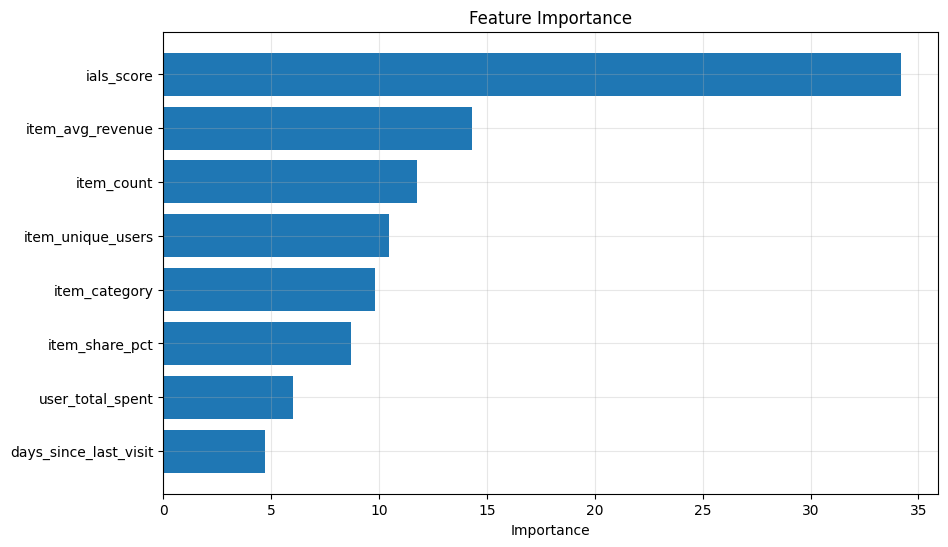

In [359]:
plt.figure(figsize=(10, 6))
plt.xlabel('Importance')
plt.title('Feature Importance')

plt.barh(feat_importances['Feature Id'], feat_importances['Importances'])

plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

### Распределение предсказаний (Prediction Probability)

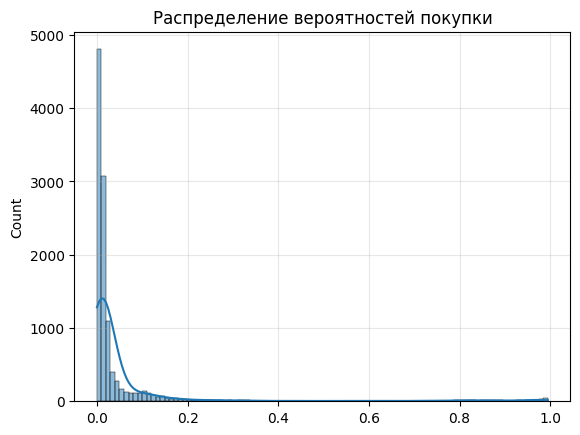

In [364]:
probs = cb_model.predict_proba(X_test)[:, 1]

plt.title('Распределение вероятностей покупки')
sns.histplot(probs, bins=100, kde=True)
plt.grid(True, alpha=0.3)
plt.show()